# 03 - Customer Analysis

**Objective:** Understand who the highest-value customers are, how loyal the
customer base is, and how revenue is distributed across customers and
segments.

**Business context:** Management wants to know whether growth depends on a
small number of accounts or is broadly distributed, and which customer
segment is most worth prioritizing.

**Privacy note:** this notebook uses `customer_id` only. `customer_name`,
`city`, `state_province`, and `postal_code` are excluded throughout, per
this project's public-repo privacy requirement (see `data/README.md`).


In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import matplotlib.pyplot as plt
from data_loading import load_orders
from data_cleaning import clean_orders
from feature_engineering import engineer_all
from kpi_calculations import customer_count, repeat_customer_rate, revenue_per_customer

raw = load_orders()
cleaned, _ = clean_orders(raw)
tables = engineer_all(cleaned)
lines = tables['lines']
customers = tables['customer_level']
print(f"Distinct customers: {customer_count(lines):,}")
print(f"Repeat customer rate: {repeat_customer_rate(lines):.2%}")
print(f"Revenue per customer: ${revenue_per_customer(lines):,.2f}")


Distinct customers: 804
Repeat customer rate: 98.51%
Revenue per customer: $2,893.70


## Top customers by revenue (by ID only)

**Business question: Who are the highest-value customers?**

In [2]:
customers.head(10)[['customer_id','segment','region','total_orders','total_sales','total_profit','avg_order_value']]

,customer_id,segment,region,total_orders,total_sales,total_profit,avg_order_value
711,SM-20320,Home Office,South,5,25043.050,-1980.7393,5008.610000
752,TC-20980,Corporate,Central,5,19052.218,8981.3239,3810.443600
632,RB-19360,Consumer,East,6,15117.339,6976.0959,2519.556500
741,TA-21385,Home Office,Central,4,14595.620,4703.7883,3648.905000
6,AB-10105,Consumer,Central,10,14473.571,5444.8055,1447.357100
443,KL-16645,Consumer,West,12,14175.229,806.8550,1181.269083
680,SC-20095,Consumer,West,9,14142.334,5757.4119,1571.370444
328,HL-15040,Consumer,South,6,12873.298,5622.4292,2145.549667
694,SE-20110,Consumer,West,11,12209.438,2650.6769,1109.948909
132,CC-12370,Consumer,East,5,12129.072,2177.0493,2425.814400


**Interpretation:** the single highest-revenue customer (`SM-20320`,
$25,043 in revenue) is actually **unprofitable** overall (-$1,981 profit) --
revenue rank and profit rank are not the same thing. Any "top customer"
program based on revenue alone would misidentify this account as a
priority.

## Order frequency distribution

**Business question: What is the repeat customer rate, and how loyal is the
base?**

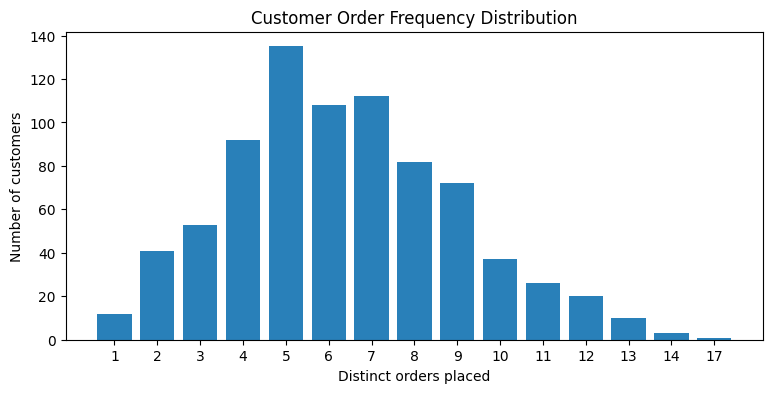

In [3]:
orders_per_customer = lines.groupby('customer_id')['order_id'].nunique()
dist = orders_per_customer.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9,4))
ax.bar(dist.index.astype(str), dist.values, color='#2980b9')
ax.set_xlabel('Distinct orders placed')
ax.set_ylabel('Number of customers')
ax.set_title('Customer Order Frequency Distribution')
plt.show()


**Interpretation:** only 12 of 804 customers (1.5%) placed exactly one
order across the full ~4-year window; the most common pattern is 5 distinct
orders (135 customers). This drives the very high 98.5% repeat-customer
rate -- but that figure should be read in the context of a multi-year
dataset, not as a short-term loyalty metric.

## Segment performance

**Business question: Which customer segment generates the most revenue?**

In [4]:
segment_summary = (lines.groupby('segment')
    .agg(revenue=('sales','sum'), profit=('profit','sum'), orders=('order_id','nunique'))
    .reset_index())
segment_summary['margin'] = segment_summary['profit']/segment_summary['revenue']
segment_summary.sort_values('revenue', ascending=False)


,segment,revenue,profit,orders,margin
0,Consumer,1.170660e+06,136371.4463,2628,0.116491
1,Corporate,7.158061e+05,94249.6400,1552,0.131669
2,Home Office,4.400684e+05,61675.7283,931,0.140150


**Interpretation:** Consumer drives the most revenue ($1.17M) but has the
**lowest** margin (11.6%) of the three segments; Home Office is the smallest
segment by revenue but the most profitable per dollar (14.0% margin).

## Revenue concentration (Pareto view)

**Business question: How concentrated is revenue among customers?**

Top 10% of customers (80 of 804) generate 30.9% of total revenue.


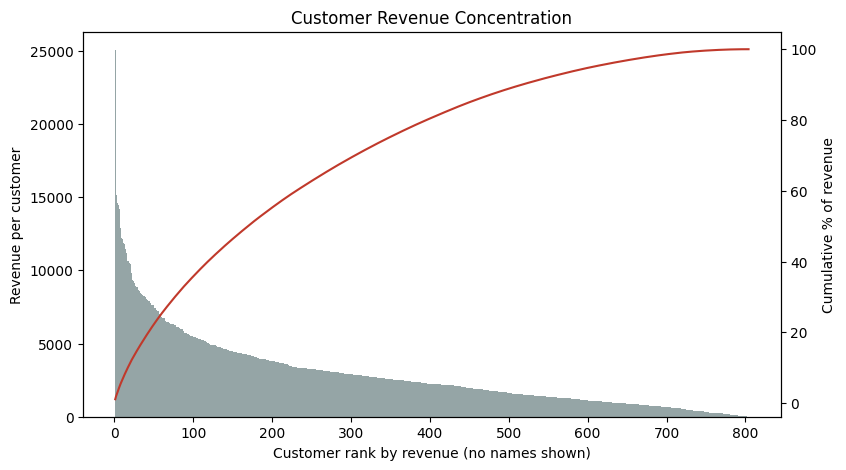

In [5]:
ranked = customers.sort_values('total_sales', ascending=False).reset_index(drop=True)
ranked['cumulative_pct'] = ranked['total_sales'].cumsum() / ranked['total_sales'].sum() * 100
top_decile_cutoff = int(len(ranked) * 0.10)
top_decile_share = ranked.loc[:top_decile_cutoff-1, 'total_sales'].sum() / ranked['total_sales'].sum()
print(f"Top 10% of customers ({top_decile_cutoff} of {len(ranked)}) generate {top_decile_share:.1%} of total revenue.")

fig, ax1 = plt.subplots(figsize=(9,5))
ax1.bar(ranked.index+1, ranked['total_sales'], color='#95a5a6', width=1.0)
ax1.set_xlabel('Customer rank by revenue (no names shown)')
ax1.set_ylabel('Revenue per customer')
ax2 = ax1.twinx()
ax2.plot(ranked.index+1, ranked['cumulative_pct'], color='#c0392b')
ax2.set_ylabel('Cumulative % of revenue')
ax1.set_title('Customer Revenue Concentration')
plt.show()


**Interpretation:** revenue is only moderately concentrated -- the top
10% of customers (~80 of 804) generate about 31% of total revenue, not the
sharper 80/20-style concentration sometimes assumed by default. Growth
depends on a broad customer base, not a handful of accounts.